In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Author: Manou Liesker. Student number: 15250946

In [3]:
NETWORK_FOLDER = Path(r"Z:\Video_Files")
input_path = str(NETWORK_FOLDER / "Reflection_Method_Test.avi")

print(input_path)

Z:\Video_Files\Reflection_Method_Test.avi


In [23]:
from pathlib import Path
import cv2
import numpy as np

NETWORK_FOLDER = Path(r"Z:\Video_Files")
input_path = str(NETWORK_FOLDER / "Reflection_Method_Test.avi")

cap = cv2.VideoCapture(input_path)

x_points = []
y_points = []
frame_numbers = []

threshold_value = 100
min_area = 3
max_area = 100
frame_idx = 0

while True:
    ret, frame = cap.read()
    if not ret:
        break

    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    gray = cv2.GaussianBlur(gray, (5, 5), 0)

    _, mask = cv2.threshold(gray, threshold_value, 255, cv2.THRESH_BINARY)

    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    small_contours = [
        cnt for cnt in contours
        if min_area <= cv2.contourArea(cnt) <= max_area
    ]

    frame_numbers.append(frame_idx)

    if small_contours:
        cnt = max(small_contours, key=cv2.contourArea)

        M = cv2.moments(cnt)
        if M["m00"] != 0:
            cx = M["m10"] / M["m00"]
            cy = M["m01"] / M["m00"]

            x_points.append(cx)
            y_points.append(cy)

            cv2.drawContours(frame, [cnt], -1, (0, 255, 0), 2)
            cv2.circle(frame, (int(cx), int(cy)), 5, (0, 0, 255), -1)
        else:
            x_points.append(np.nan)
            y_points.append(np.nan)
    else:
        x_points.append(np.nan)
        y_points.append(np.nan)

    cv2.imshow("tracking", frame)
    cv2.imshow("mask", mask)

    if cv2.waitKey(30) == 27:
        break

    frame_idx += 1

cap.release()
cv2.destroyAllWindows()

print("Number of frames:", len(frame_numbers))
print("Number of x points:", len(x_points))
print("Number of y points:", len(y_points))

Number of frames: 403
Number of x points: 403
Number of y points: 403


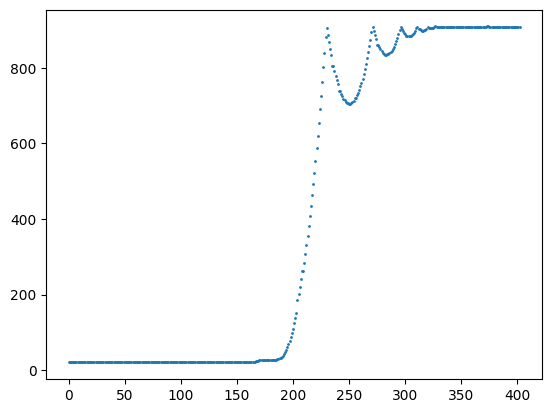

In [24]:
plt.scatter(frame_numbers, y_points, s = 1)
plt.show()